In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
harcamalar=pd.DataFrame({"Tarih":["01.08.2026","02.08.2026","03.08.2026"],
            "Kategori":["Market","Ulasım","Eglence"],
            "Acıklama":["Migros","Benzin","Sinema"],
            "Tutar":[850,1500,400]})

In [14]:
harcamalar

,Tarih,Kategori,Acıklama,Tutar
0,01.08.2026,Market,Migros,850
1,02.08.2026,Ulasım,Benzin,1500
2,03.08.2026,Eglence,Sinema,400


In [23]:
aylik_butce=int(input("Aylık bütçe girin:"))      

In [25]:
x=harcamalar["Tutar"].sum()

In [26]:
if x>aylik_butce:
    print("Aylık bütçe aşıldı!")
else:
    print("Aylık bütçe aşılmadı")


Aylık bütçe aşılmadı


In [30]:
en_yuksek_tutar = 0
en_yuksek_kategori = ""

for kategori, tutar in zip(harcamalar["Kategori"], harcamalar["Tutar"]):
    if tutar > en_yuksek_tutar:
        en_yuksek_tutar = tutar
        en_yuksek_kategori = kategori

print(f"En yüksek harcama: {en_yuksek_kategori} -> {en_yuksek_tutar} TL")

En yüksek harcama: Ulasım -> 1500 TL


In [31]:
class Expense():
    def __init__(self,tarih,kategori,aciklama,tutar):
        self.tarih=tarih
        self.kategori=kategori
        self.aciklama=aciklama
        self.tutar=tutar

In [34]:
class BudgetAnalyzer():
    def __init__(self,butce):
        self.butce=butce
        self.harcamalar=[]
    def harcama_ekle(self,harcama):
        self.harcamalar.append(harcama)
    def toplam_harcama_hesapla(self):
       toplam=0
       for h in self.harcamalar:
           toplam+=h.tutar
       return toplam 
    def butce_kontrolu(self):
        toplam=self.toplam_harcama_hesapla()
        if toplam>self.butce:
            print(f"Bütçe aşıldı! Toplam Harcama: {toplam} TL, Bütçe: {self.butce} TL")
        else:
            print(f"Bütçe dahilindesiniz. Kalan bütçe: {self.butce - toplam} TL")
    def kategori_analizi(self):
        kategori_ozeti = {}
        for h in self.harcamalar:
            if h.kategori in kategori_ozeti:
                kategori_ozeti[h.kategori]+=h.tutar
            else:
                kategori_ozeti[h.kategori] = h.tutar
            return kategori_ozeti



In [46]:
np.mean(harcamalar["Tutar"])

np.float64(916.6666666666666)

In [47]:
np.std(harcamalar["Tutar"])

np.float64(451.5405728048022)

In [48]:
np.min(harcamalar["Tutar"])

np.int64(400)

In [49]:
np.max(harcamalar["Tutar"])

np.int64(1500)

In [50]:
np.median(harcamalar["Tutar"])

np.float64(850.0)

In [53]:
df = pd.DataFrame(harcamalar)
df.to_csv("harcamalar.csv", index=False)


In [54]:
okunan_harcamalar = pd.read_csv("harcamalar.csv")

In [55]:
okunan_harcamalar

,Tarih,Kategori,Acıklama,Tutar
0,01.08.2026,Market,Migros,850
1,02.08.2026,Ulasım,Benzin,1500
2,03.08.2026,Eglence,Sinema,400


In [57]:
okunan_harcamalar.groupby("Kategori")["Tutar"].sum()

Kategori
Eglence     400
Market      850
Ulasım     1500
Name: Tutar, dtype: int64

In [65]:
okunan_harcamalar.groupby("Tarih")["Tutar"].sum()

Tarih
01.08.2026     850
02.08.2026    1500
03.08.2026     400
Name: Tutar, dtype: int64

In [70]:
okunan_harcamalar.sort_values(by="Tutar",ascending=False).head(5)

,Tarih,Kategori,Acıklama,Tutar
1,02.08.2026,Ulasım,Benzin,1500
0,01.08.2026,Market,Migros,850
2,03.08.2026,Eglence,Sinema,400


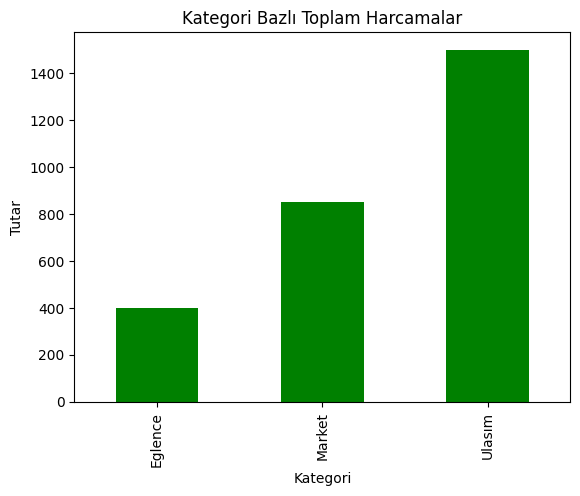

In [74]:
kategori_toplam = okunan_harcamalar.groupby("Kategori")["Tutar"].sum()
kategori_toplam.plot(kind="bar",color="g")
plt.title("Kategori Bazlı Toplam Harcamalar")
plt.xlabel("Kategori")
plt.ylabel("Tutar")
plt.show()

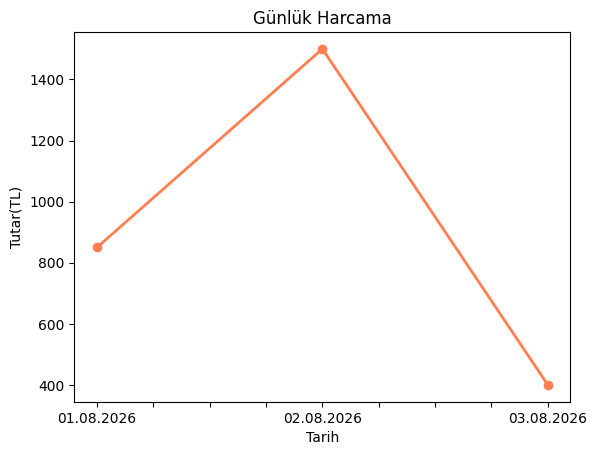

In [76]:
gunluk_toplam = okunan_harcamalar.groupby("Tarih")["Tutar"].sum()
gunluk_toplam.plot(kind="line",marker="o",color="coral",linewidth=2)
plt.title("Günlük Harcama")
plt.xlabel("Tarih")
plt.ylabel("Tutar(TL)")
plt.show()

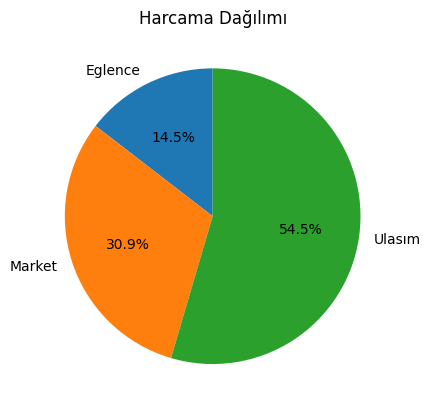

In [79]:
kategori_toplam = okunan_harcamalar.groupby("Kategori")["Tutar"].sum()

kategori_toplam.plot(kind="pie", autopct="%1.1f%%",startangle=90)
plt.title("Harcama Dağılımı")
plt.ylabel("")  
plt.show()